1. Importar librerias

In [136]:
from openseespy.opensees import *
import matplotlib.pyplot as plt
import opsvis as opsv
import numpy as np
import math

2. Creación del modelo 2D

In [137]:
wipe()
model('basic','-ndm',3,'-ndf',6)

3. Creación de nodos y apoyos

In [138]:
#el plano es XY y la altura es Z

x1=6.0 #en metros
y1=4.0
z1=4.0
z2=8.0

#nivel cero
node(1,0.0,0.0,0.0)
node(2,x1,0.0,0.0)
node(3,0.0,y1,0.0)
node(4,x1,y1,0.0)

#entrepiso 1
node(5,0.0,0.0,z1)
node(6,x1,0.0,z1)
node(7,0.0,y1,z1)
node(8,x1,y1,z1)

#nivel de techo
node(9,0.0,0.0,z2)
node(10,x1,0.0,z2)
node(11,0.0,y1,z2)
node(12,x1,y1,z2)

#Apoyos
empotrado=[1,1,1,1,1,1]
fix(1,*empotrado)
fix(2,*empotrado)
fix(3,*empotrado)
fix(4,*empotrado)


#Diafragma rigido de entrepiso
#Crear los nodos en el centro de masa
node(101, 3.0, 2.0, 4.0)
node(102, 3.0, 2.0, 8.0)

fix(101, 0, 0, 1, 1, 1, 0)
fix(102, 0, 0, 1, 1, 1, 0)

#Asignar la masa en el nodo del centro de masa 1kN en cada nodo=4kN
M_piso = 4.0 #kN
mass(101, M_piso, M_piso,0.0 , 0.0, 0.0, 0.0) #se podría asignar masa para los grados rotacionales, calculando la inercia masica polar
mass(102, M_piso, M_piso, 0.0, 0.0, 0.0, 0.0)
rigidDiaphragm(3, 101, 5, 6, 7, 8)
rigidDiaphragm(3, 102, 9, 10, 11, 12)

4. Creación de las secciones trasnversales

In [139]:
E_col=200e6 #MPa
G_col=77e6 #MPa
A_col = 0.00419   # Área perfil W10x22 en m4
I_col_z = 0.0000491  # Inercia W10x22 en m4
I_col_y = 0.00000483  # Inercia eje debil
J_col=0.000000191

E_viga=200e6 #MPa
G_viga=77e6 #MPa
A_viga = 0.00419 
I_viga_z = 0.0000491  # Inercia W10x22 en m4
I_viga_y = 0.00000483  # Inercia eje debil
J_viga=0.000000191

geomTransf('Linear', 1, 0.0, 1.0, 0.0)
geomTransf('Linear', 2, 0.0, -1.0, 0.0)
geomTransf('Linear', 3, 1.0, 0.0, 0.0)

6. Creación de elementos

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

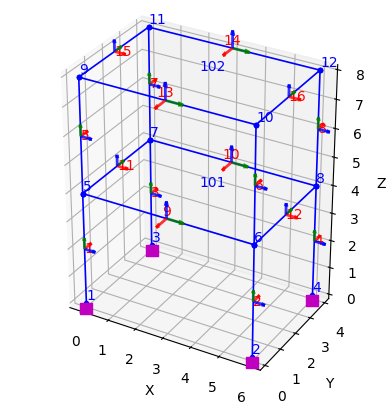

In [140]:
#Columnas
element('elasticBeamColumn', 1, 1, 5, A_col*1e6,E_col,G_col,J_col,I_col_y,I_col_z,1)
element('elasticBeamColumn', 2, 2, 6, A_col*1e6, E_col, G_col, J_col, I_col_y, I_col_z, 1)
element('elasticBeamColumn', 3, 3, 7, A_col*1e6, E_col, G_col, J_col, I_col_y, I_col_z, 1)
element('elasticBeamColumn', 4, 4, 8, A_col*1e6, E_col, G_col, J_col, I_col_y, I_col_z, 1)

element('elasticBeamColumn', 5, 5, 9, A_col*1e6, E_col, G_col, J_col, I_col_y, I_col_z, 1)
element('elasticBeamColumn', 6, 6, 10, A_col*1e6, E_col, G_col, J_col, I_col_y, I_col_z, 1)
element('elasticBeamColumn', 7, 7, 11, A_col*1e6, E_col, G_col, J_col, I_col_y, I_col_z, 1)
element('elasticBeamColumn', 8, 8, 12, A_col*1e6, E_col, G_col, J_col, I_col_y, I_col_z, 1)


#Vigas
element('elasticBeamColumn', 9, 5, 6, A_viga, E_viga, G_viga, J_viga, I_viga_y*1e6, I_viga_z*1e6, 2) 
element('elasticBeamColumn', 10, 7, 8, A_viga, E_viga, G_viga, J_viga, I_viga_y*1e6, I_viga_z*1e6, 2)
element('elasticBeamColumn', 11, 5, 7, A_viga, E_viga, G_viga, J_viga, I_viga_y*1e6, I_viga_z*1e6, 3)
element('elasticBeamColumn', 12, 6, 8, A_viga, E_viga, G_viga, J_viga, I_viga_y*1e6, I_viga_z*1e6, 3)
element('elasticBeamColumn', 13, 9, 10, A_viga, E_viga, G_viga, J_viga, I_viga_y*1e6, I_viga_z*1e6, 2)
element('elasticBeamColumn', 14, 11, 12, A_viga, E_viga, G_viga, J_viga, I_viga_y*1e6, I_viga_z*1e6, 2)
element('elasticBeamColumn', 15, 9, 11, A_viga, E_viga, G_viga, J_viga, I_viga_y*1e6, I_viga_z*1e6, 3)
element('elasticBeamColumn', 16, 10, 12, A_viga, E_viga, G_viga, J_viga, I_viga_y*1e6, I_viga_z*1e6, 3)

opsv.plot_model()

Aplicación de cargas

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

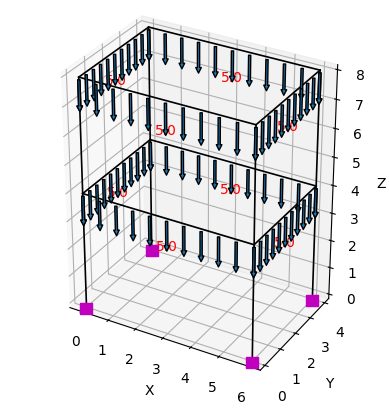

In [141]:
timeSeries('Linear',1)
pattern('Plain',1,1)

vigas=[9,10,11,12,13,14,15,16] #Tags de los elementos viga
wviga=5 #kN valor de carga distribuida sobre la viga
eleLoad('-ele',*vigas,'-type','beamUniform',-wviga,0.0,0.0)

opsv.plot_load()

Análisis estático

In [142]:
system('UmfPack')
numberer('RCM')
constraints('Transformation')
test('NormDispIncr', 1.0e-8, 10)
algorithm('Newton')
integrator('LoadControl', 0.1)
analysis('Static')

analyze(10)
loadConst('-time', 0.0)
print("Análisis de Gravedad Completado.")

Análisis de Gravedad Completado.


Cálculo del periodo fundamental

Periodos: T1=0.76s, T2=0.29s, T3=0.24s


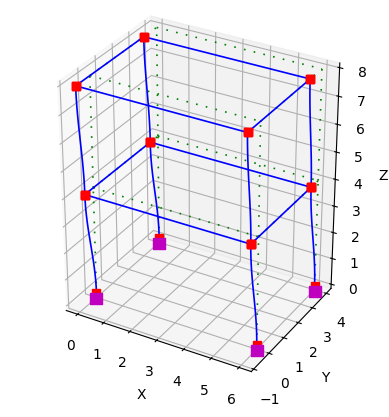

In [143]:
eig=eigen('-fullGenLapack', 3) #calcula las frecuencias de la canitdad de modos indicada, en este caos 1. esto es w^2
T1=2*3.1416/np.sqrt(eig[0])
T2=2*3.1416/np.sqrt(eig[1])
T3=2*3.1416/np.sqrt(eig[2])
print(f"Periodos: T1={T1:.2f}s, T2={T2:.2f}s, T3={T3:.2f}s")

opsv.plot_mode_shape(1)

Registro sismico

In [144]:
xi = 0.05  # 5% de amortiguamiento

# Se extraen las frecuencias angulares de los dos únicos modos del sistema
wn1 = np.sqrt(eig[0])
wn2 = np.sqrt(eig[1])

# Cálculo de coeficientes de Rayleigh (Masa y Rigidez Inicial)
a0 = xi * (2.0 * wn1 * wn2) / (wn1 + wn2)
a1 = xi * 2.0 / (wn1 + wn2)

# Asignación en OpenSees: rayleigh(alphaM, betaKcurr, betaKinit, betaKcomm)
# Usaremos la rigidez inicial (betaKinit = a1)
rayleigh(a0, 0.0, a1, 0.0)


wipeAnalysis()

dt = 0.01
npts = 3000
g = 9.81 # m/s2 (Factor de escala para pasar de fracciones de g a aceleración)

# Serie de tiempo leyendo el archivo txt
timeSeries('Path', 2, '-filePath', 'Sismo1.txt', '-dt', dt, '-factor', g)

# Patrón de carga de excitación en la base (Dirección 1 = X)
pattern('UniformExcitation', 2, 1, '-accel', 2)


Análisis dinámico

In [145]:
constraints('Transformation') # Necesario por el uso de equalDOF
numberer('RCM')
system('BandGeneral')
test('NormDispIncr', 1.0e-8, 10, 0) # Tolerancia estricta
algorithm('Newton')
integrator('Newmark', 0.5, 0.25)    # Aceleración promedio (Incondicionalmente estable)
analysis('Transient')


#iniciar variables de salida

time_out = np.zeros(npts)
disp_techo = np.zeros(npts)
disp_entrepiso = np.zeros(npts)
deriva_techo = np.zeros(npts)
fuerzas_col1=np.zeros(npts)
fuerzas_viga9=np.zeros(npts)
max_disp_6 = 0.0
max_disp_10 = 0.0
max_f_axial_col1=0.0

#CALCULO DE LOS DESPLAZAMIENTOS, DERIVAS Y FUERZAS
h_piso2 =z2-z1 # Altura del segundo piso (4.0 m)

for i in range(npts):
    ok = analyze(1, dt)
    if ok != 0:
        print(f"El análisis falló en el paso {i}, t = {getTime():.2f} s")
        break
    
    time_out[i] = getTime() #tiempo actual
    
    # Extraer desplazamientos en X (GDL 1) de los nodos 6 (Techo) y 4 (Piso 1)
    u_techo = nodeDisp(10, 1)
    u_piso1 = nodeDisp(6, 1)

    #Extraer fuerzas
    f_col1 = eleForce(1)
    f_viga9 = eleForce(9)
    
    # Almacenar desplazamiento total del techo
    disp_techo[i] = u_techo
    disp_entrepiso[i] = u_piso1
    fuerzas_col1[i]= f_col1[0] #fuerza axial
    fuerzas_viga9[i] = f_viga9[2] #momento flector


    # Calcular y almacenar la deriva del techo (Drift del piso 2)
    deriva_techo[i] = (u_techo - u_piso1) / h_piso2
    
    # Actualizar máximos absolutos
    if abs(u_piso1) > max_disp_6:
        max_disp_6 = abs(u_piso1)
    if abs(u_techo) > max_disp_10:
        max_disp_10 = abs(u_techo)
    if abs(f_col1[0]) > max_f_axial_col1:
        max_f_axial_col1 = abs(f_col1[0])

print("Análisis dinámico completado con éxito.")

Análisis dinámico completado con éxito.


Visualización de resultados

Desplazamiento Máximo Nudo 6 (Piso 1): 0.00773 m
Desplazamiento Máximo Nudo 10 (Piso 2): 0.01242 m
Fuerza Axial Máxima en la base (Columna 1): 14.24 kN


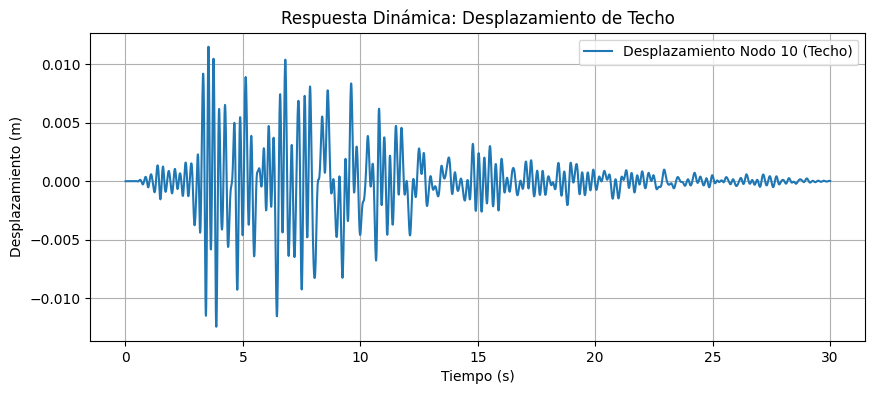

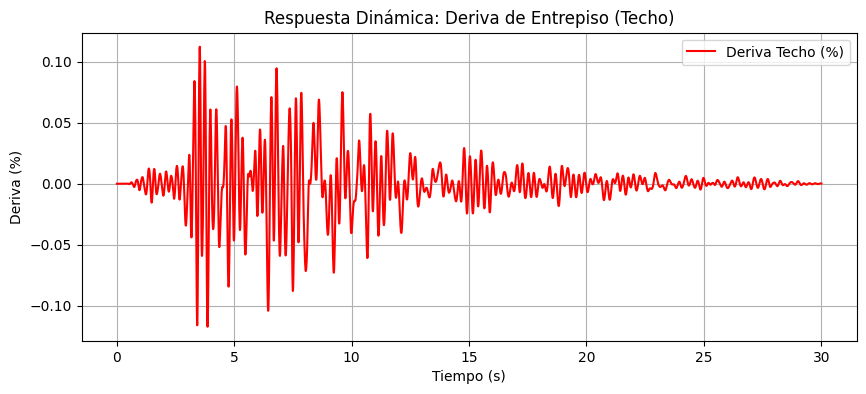

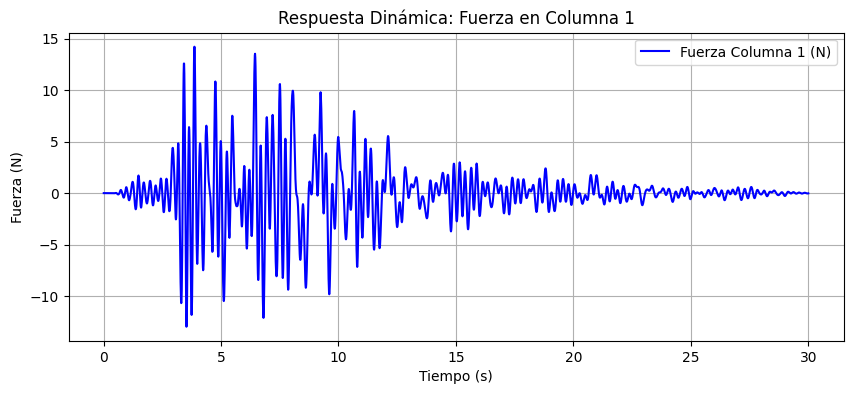

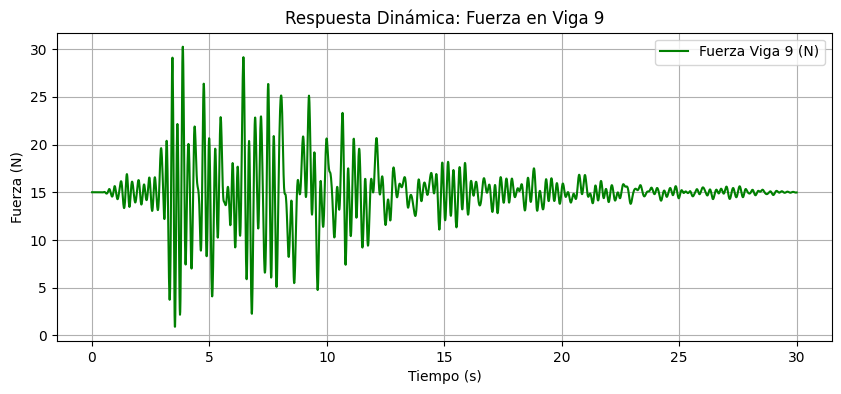

In [146]:
#DESPLAZAMIENTO MÁXIMO DE LOS NODOS 6 y 10
print(f"Desplazamiento Máximo Nudo 6 (Piso 1): {max_disp_6:.5f} m")
print(f"Desplazamiento Máximo Nudo 10 (Piso 2): {max_disp_10:.5f} m")
print(f"Fuerza Axial Máxima en la base (Columna 1): {max_f_axial_col1:.2f} kN")


#DESPLAZAMIENTOS DE TECHO EN EL TIEMPO
plt.figure(figsize=(10, 4))
plt.plot(time_out, disp_techo, label='Desplazamiento Nodo 10 (Techo)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Desplazamiento (m)')
plt.title('Respuesta Dinámica: Desplazamiento de Techo')
plt.grid(True)
plt.legend()
plt.show()

#DERIVA DE TECHO EN EL TIEMPO
plt.figure(figsize=(10, 4))
plt.plot(time_out, deriva_techo * 100, color='red', label='Deriva Techo (%)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Deriva (%)')
plt.title('Respuesta Dinámica: Deriva de Entrepiso (Techo)')
plt.grid(True)
plt.legend()
plt.show()

#FUERZA AXIAL COLUMNA 1 EN EL TIEMPO

plt.figure(figsize=(10, 4))
plt.plot(time_out, fuerzas_col1, color='blue', label='Fuerza Columna 1 (N)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Fuerza (N)')
plt.title('Respuesta Dinámica: Fuerza en Columna 1')
plt.grid(True)
plt.legend()
plt.show()

#FUERZA VIGA 9 EN EL TIEMPO
plt.figure(figsize=(10, 4))
plt.plot(time_out, fuerzas_viga9, color='green', label='Fuerza Viga 9 (N)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Fuerza (N)')
plt.title('Respuesta Dinámica: Fuerza en Viga 9')
plt.grid(True)
plt.legend()
plt.show()
